In [1]:
import pandas as pd

df_sms = pd.read_csv(
    "../data/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

df_sms.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
print("Dataset Shape:", df_sms.shape)

Dataset Shape: (5572, 2)


In [3]:
df_sms.columns

Index(['label', 'message'], dtype='str')

In [4]:
df_sms.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 542.9 KB


In [5]:
df_sms.duplicated().sum()

np.int64(403)

In [6]:
df_sms["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
df_sms["label"].value_counts(normalize=True) * 100

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

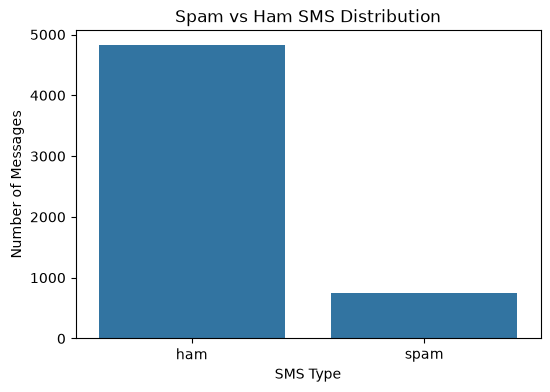

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_sms,
    x="label"
)

plt.title("Spam vs Ham SMS Distribution")
plt.xlabel("SMS Type")
plt.ylabel("Number of Messages")

plt.show()

In [24]:
df_sms["message_length"] = df_sms["message"].str.len()

In [10]:
df_sms["message_length"].describe()

count    5572.000000
mean       80.489950
std        59.942907
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: message_length, dtype: float64

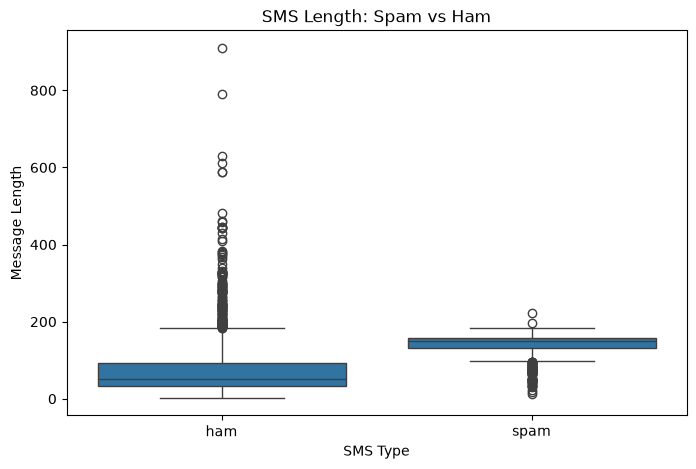

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_sms,
    x="label",
    y="message_length"
)

plt.title("SMS Length: Spam vs Ham")
plt.xlabel("SMS Type")
plt.ylabel("Message Length")

plt.show()

In [12]:
from collections import Counter
import re

In [13]:
def get_words(text):
    return re.findall(
        r"\b[a-zA-Z]+\b",
        str(text).lower()
    )

In [14]:
spam_words = []

for text in df_sms[df_sms["label"] == "spam"]["message"]:
    spam_words.extend(get_words(text))

spam_word_counts = Counter(spam_words)

print("Top 20 words in Spam SMS:")
print(spam_word_counts.most_common(20))

Top 20 words in Spam SMS:
[('to', 691), ('a', 380), ('call', 355), ('you', 297), ('your', 264), ('free', 224), ('the', 206), ('for', 204), ('now', 199), ('or', 188), ('u', 174), ('txt', 163), ('is', 158), ('on', 145), ('ur', 144), ('have', 135), ('from', 131), ('mobile', 127), ('text', 125), ('stop', 123)]


In [15]:
ham_words = []

for text in df_sms[df_sms["label"] == "ham"]["message"]:
    ham_words.extend(get_words(text))

ham_word_counts = Counter(ham_words)

print("Top 20 words in Ham SMS:")
print(ham_word_counts.most_common(20))

Top 20 words in Ham SMS:
[('i', 2960), ('you', 1948), ('to', 1562), ('the', 1133), ('a', 1070), ('u', 1033), ('and', 858), ('in', 823), ('me', 777), ('my', 754), ('is', 739), ('it', 718), ('that', 560), ('of', 526), ('for', 507), ('s', 490), ('have', 443), ('can', 441), ('but', 441), ('so', 436)]


In [16]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
def get_meaningful_words(text):

    words = re.findall(
        r"\b[a-zA-Z]+\b",
        str(text).lower()
    )

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return words

In [18]:
spam_words = []

for text in df_sms[df_sms["label"] == "spam"]["message"]:
    spam_words.extend(get_meaningful_words(text))

spam_word_counts = Counter(spam_words)

print("Top 20 Meaningful Words in Spam SMS:")
print(spam_word_counts.most_common(20))

Top 20 Meaningful Words in Spam SMS:
[('call', 355), ('free', 224), ('u', 174), ('txt', 163), ('ur', 144), ('mobile', 127), ('text', 125), ('stop', 123), ('claim', 113), ('reply', 104), ('www', 98), ('prize', 93), ('get', 86), ('cash', 76), ('uk', 74), ('send', 71), ('new', 69), ('nokia', 67), ('win', 64), ('urgent', 63)]


In [19]:
ham_words = []

for text in df_sms[df_sms["label"] == "ham"]["message"]:
    ham_words.extend(get_meaningful_words(text))

ham_word_counts = Counter(ham_words)

print("Top 20 Meaningful Words in Ham SMS:")
print(ham_word_counts.most_common(20))

Top 20 Meaningful Words in Ham SMS:
[('u', 1033), ('gt', 318), ('lt', 316), ('get', 305), ('ok', 288), ('go', 252), ('ur', 247), ('call', 238), ('know', 237), ('good', 235), ('like', 234), ('got', 233), ('come', 230), ('day', 212), ('love', 205), ('time', 202), ('going', 169), ('one', 168), ('home', 165), ('want', 165)]


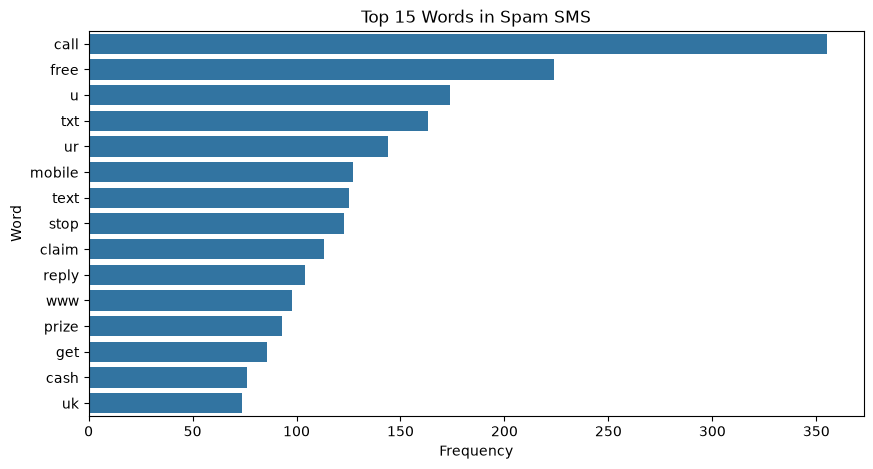

In [20]:
top_spam = spam_word_counts.most_common(15)

words = [item[0] for item in top_spam]
counts = [item[1] for item in top_spam]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 15 Words in Spam SMS")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

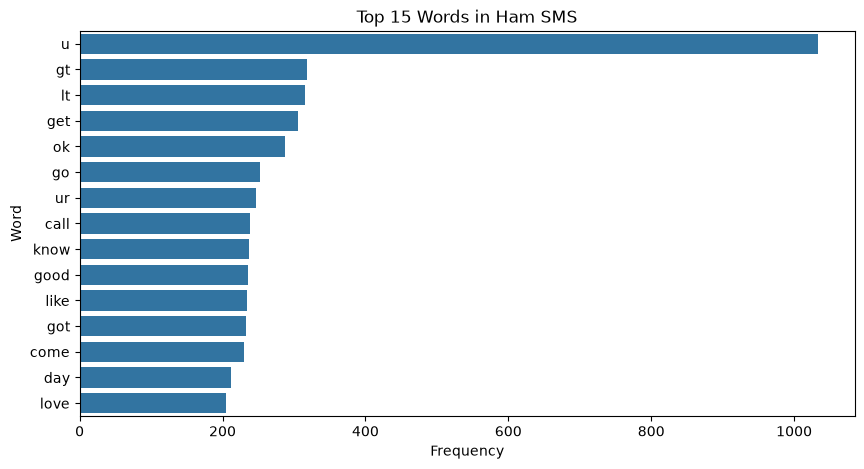

In [21]:
top_ham = ham_word_counts.most_common(15)

words = [item[0] for item in top_ham]
counts = [item[1] for item in top_ham]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 15 Words in Ham SMS")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

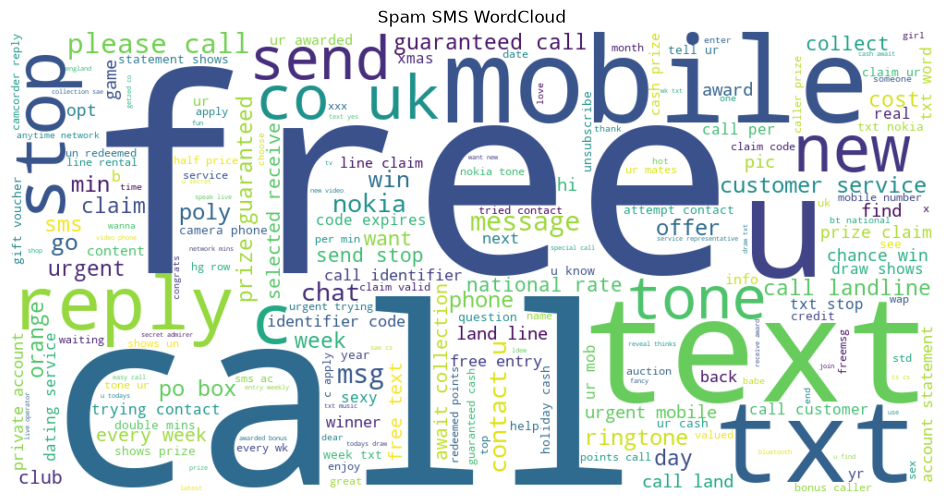

In [22]:
from wordcloud import WordCloud

spam_text = " ".join(spam_words)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Spam SMS WordCloud")

plt.show()

In [25]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [26]:
def clean_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Keep only alphabetic words
    words = re.findall(r"\b[a-zA-Z]+\b", text)

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [27]:
df_sms["clean_text"] = df_sms["message"].apply(clean_text)

In [28]:
df_sms["clean_text"] = df_sms["message"].apply(clean_text)

In [29]:
df_sms["target"] = df_sms["label"].map({
    "ham": 0,
    "spam": 1
})

In [30]:
df_sms[["label", "target"]].head(10)

,label,target
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0
5,spam,1
6,ham,0
7,ham,0
8,spam,1
9,spam,1


In [31]:
X = df_sms["clean_text"]
y = df_sms["target"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_sms = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [34]:
X_train_tfidf = tfidf_sms.fit_transform(X_train)

In [35]:
X_test_tfidf = tfidf_sms.transform(X_test)

In [36]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4457, 5000)
Testing TF-IDF shape: (1115, 5000)


In [37]:
from sklearn.linear_model import LogisticRegression

sms_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

sms_lr.fit(X_train_tfidf, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [38]:
y_pred_lr = sms_lr.predict(X_test_tfidf)

In [39]:
from sklearn.metrics import accuracy_score, classification_report

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Ham", "Spam"]
    )
)

Logistic Regression Accuracy: 0.9748878923766816
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       966
        Spam       0.90      0.91      0.91       149

    accuracy                           0.97      1115
   macro avg       0.94      0.95      0.95      1115
weighted avg       0.98      0.97      0.97      1115



In [40]:
from sklearn.naive_bayes import MultinomialNB

sms_nb = MultinomialNB()

sms_nb.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb = sms_nb.predict(
    X_test_tfidf
)

In [41]:
print(
    "Naive Bayes Accuracy:",
    accuracy_score(y_test, y_pred_nb)
)

print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Ham", "Spam"]
    )
)

Naive Bayes Accuracy: 0.9748878923766816
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       966
        Spam       0.99      0.82      0.90       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



In [42]:
from sklearn.svm import LinearSVC

sms_svm = LinearSVC(
    class_weight="balanced"
)

sms_svm.fit(
    X_train_tfidf,
    y_train
)

y_pred_svm = sms_svm.predict(
    X_test_tfidf
)

In [43]:
print(
    "SVM Accuracy:",
    accuracy_score(y_test, y_pred_svm)
)

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["Ham", "Spam"]
    )
)

SVM Accuracy: 0.9775784753363229
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.94      0.89      0.91       149

    accuracy                           0.98      1115
   macro avg       0.96      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

sms_results = []

models_predictions = {
    "Logistic Regression": y_pred_lr,
    "Naive Bayes": y_pred_nb,
    "SVM": y_pred_svm
}

for model_name, predictions in models_predictions.items():

    sms_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1 Score": f1_score(
            y_test,
            predictions
        )
    })

sms_results_df = pd.DataFrame(sms_results)

sms_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.974888,0.900662,0.912752,0.906667
1,Naive Bayes,0.974888,0.991870,0.818792,0.897059
2,SVM,0.977578,0.936620,0.892617,0.914089


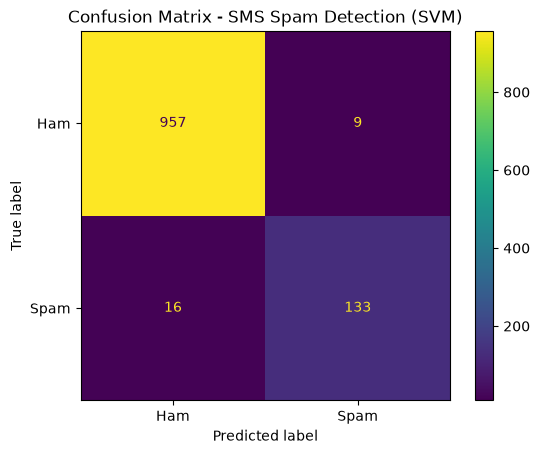

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()

plt.title("Confusion Matrix - SMS Spam Detection (SVM)")
plt.show()

In [46]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    sms_svm,
    "../models/sms_scam_model.pkl"
)

joblib.dump(
    tfidf_sms,
    "../models/sms_tfidf_vectorizer.pkl"
)

print("SMS model saved successfully!")

SMS model saved successfully!


In [47]:
new_sms = """
Congratulations! You have won ₹50,000.
Click this link immediately to claim your prize.
"""

new_sms_clean = clean_text(new_sms)

new_sms_tfidf = tfidf_sms.transform(
    [new_sms_clean]
)

prediction = sms_svm.predict(
    new_sms_tfidf
)[0]

if prediction == 1:
    print("🚨 SPAM / SCAM SMS")
else:
    print("✅ HAM / LEGITIMATE SMS")

🚨 SPAM / SCAM SMS


In [48]:
new_sms = """
Hi, I will reach college at 10 AM.
Please wait for me.
"""

new_sms_clean = clean_text(new_sms)

new_sms_tfidf = tfidf_sms.transform(
    [new_sms_clean]
)

prediction = sms_svm.predict(
    new_sms_tfidf
)[0]

if prediction == 1:
    print("🚨 SPAM / SCAM SMS")
else:
    print("✅ HAM / LEGITIMATE SMS")

✅ HAM / LEGITIMATE SMS


In [49]:
def predict_sms(message):

    # Clean SMS
    cleaned = clean_text(message)

    # TF-IDF
    vectorized = tfidf_sms.transform([cleaned])

    # Prediction
    prediction = sms_svm.predict(vectorized)[0]

    # SVM confidence score
    decision_score = sms_svm.decision_function(vectorized)[0]

    if prediction == 1:
        result = "SPAM / SCAM"
    else:
        result = "HAM / LEGITIMATE"

    return result, decision_score

In [50]:
sms = """
Congratulations! You have won ₹50,000.
Click the link immediately to claim your prize.
"""

result, score = predict_sms(sms)

print("Result:", result)
print("Decision Score:", score)

Result: SPAM / SCAM
Decision Score: 0.9265471281200788


In [51]:
sms = """
Hi, I will reach college at 10 AM.
Please wait for me.
"""

result, score = predict_sms(sms)

print("Result:", result)
print("Decision Score:", score)

Result: HAM / LEGITIMATE
Decision Score: -1.110392741607512


In [52]:
def detect_sms_indicators(text):

    text_lower = text.lower()

    indicators = []

    if any(word in text_lower for word in [
        "won", "winner", "prize", "lottery",
        "reward", "congratulations"
    ]):
        indicators.append(
            "Contains prize, lottery, or reward language"
        )

    if any(word in text_lower for word in [
        "click", "click here", "open link",
        "visit link"
    ]):
        indicators.append(
            "Contains a request to click or open a link"
        )

    if any(word in text_lower for word in [
        "urgent", "immediately", "act now",
        "limited time", "hurry"
    ]):
        indicators.append(
            "Uses urgent or pressure-based language"
        )

    if any(word in text_lower for word in [
        "bank", "account", "otp", "password",
        "pin", "credit card"
    ]):
        indicators.append(
            "Mentions potentially sensitive financial information"
        )

    if any(word in text_lower for word in [
        "money", "cash", "payment", "pay",
        "fee", "transfer"
    ]):
        indicators.append(
            "Contains payment or money-related language"
        )

    return indicators

In [53]:
sms = """
Congratulations! You have won ₹50,000.
Click the link immediately to claim your prize.
"""

indicators = detect_sms_indicators(sms)

for indicator in indicators:
    print("⚠️", indicator)

⚠️ Contains prize, lottery, or reward language
⚠️ Contains a request to click or open a link
⚠️ Uses urgent or pressure-based language


In [55]:
def get_sms_risk(prediction, indicators):

    if prediction == 0:
        return 10, "LOW"

    indicator_count = len(indicators)

    if indicator_count >= 4:
        return 95, "CRITICAL"

    elif indicator_count >= 3:
        return 85, "HIGH"

    elif indicator_count >= 2:
        return 70, "HIGH"

    elif indicator_count >= 1:
        return 55, "MEDIUM"

    else:
        return 40, "MEDIUM"